# Laboratory Task 4

PyTorch Linear Regression

**Instruction:** Train a linear regression model in PyTorch using a regression dataset. Use the following parameters:

* Criterion: MSE Loss

* Fully Connected Layers: x 2

* Batch Size: 8

* Optimizer: SGD

* Epochs: 1000

Epoch [   1/1000] - Loss: 156.9737
Epoch [ 100/1000] - Loss: 1.8217
Epoch [ 200/1000] - Loss: 1.7896
Epoch [ 300/1000] - Loss: 1.8790
Epoch [ 400/1000] - Loss: 1.8192
Epoch [ 500/1000] - Loss: 1.8006
Epoch [ 600/1000] - Loss: 1.7765
Epoch [ 700/1000] - Loss: 1.7955
Epoch [ 800/1000] - Loss: 1.8636
Epoch [ 900/1000] - Loss: 1.7759
Epoch [1000/1000] - Loss: 1.8425


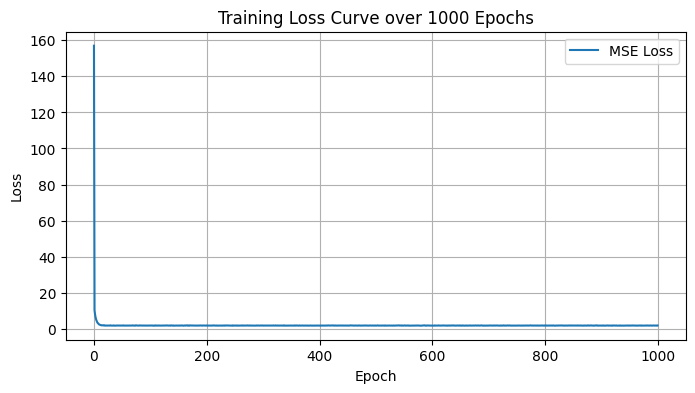

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# 1. Setup reproducibility seed
torch.manual_seed(42)

# 2. Generate synthetic regression dataset (y = 3.5 * X + 2.0 + noise)
X_data = torch.randn(100, 1) * 5.0
noise = torch.randn(100, 1) * 1.5
y_data = 3.5 * X_data + 2.0 + noise

# 3. Data Loader setup with Batch Size = 8
dataset = TensorDataset(X_data, y_data)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# 4. Model Architecture: 2 Fully Connected Layers
class TwoLayerLinearRegression(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(TwoLayerLinearRegression, self).__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.fc2 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        out = self.fc1(x)
        out = self.fc2(out)
        return out

model = TwoLayerLinearRegression(in_features=1, hidden_features=4, out_features=1)

# 5. Loss Function and Optimizer Setup
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

# 6. Training Loop
epochs = 1000
loss_history = []

for epoch in range(1, epochs + 1):
    epoch_loss = 0.0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)

    total_epoch_loss = epoch_loss / len(dataset)
    loss_history.append(total_epoch_loss)

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch [{epoch:4d}/{epochs}] - Loss: {total_epoch_loss:.4f}")

# 7. Plotting Training Loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve over 1000 Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation: Visualizing Predictions

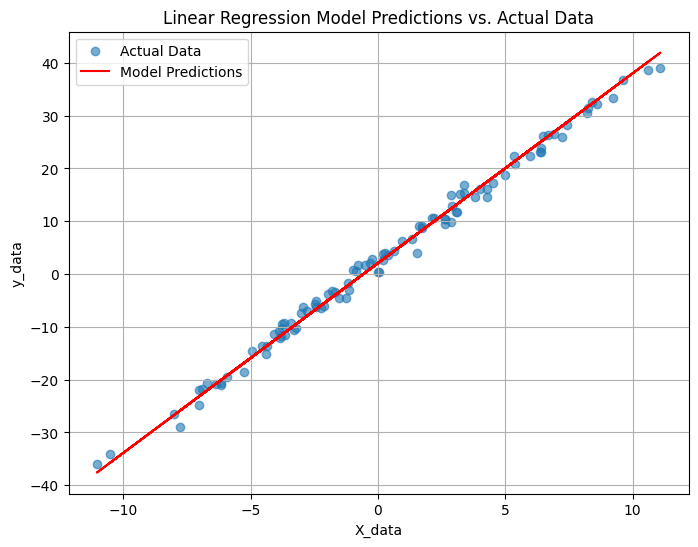

In [ ]:
# 8. Visualize the model's predictions against the actual data
model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation during inference
    predicted_values = model(X_data).numpy()

plt.figure(figsize=(8, 6))
plt.scatter(X_data.numpy(), y_data.numpy(), label='Actual Data', alpha=0.6)
plt.plot(X_data.numpy(), predicted_values, color='red', label='Model Predictions')
plt.xlabel('X_data')
plt.ylabel('y_data')
plt.title('Linear Regression Model Predictions vs. Actual Data')
plt.legend()
plt.grid(True)
plt.show()

**Key Takeaways**

Implementing a two-layer linear regression model in PyTorch highlights how structural choices affect network capacity and parameter optimization. When using two linear layers back-to-back without an intervening non-linear activation function, the network simplifies mathematically to a single linear transformation since combining two matrix multiplications is equivalent to one matrix multiplication. Setting a batch size of 8 allows stochastic gradient descent (SGD) to compute parameter updates on mini-batches, balancing numerical stability with training efficiency across the 1000 epochs. Mean Squared Error (MSE) loss provides a direct penalty metric for continuous prediction errors, driving SGD to converge toward optimal weight values.